# **Problem Statement**


---



**Fragment length frequency**

You are given a file (see link below) with each line indicating where a DNA fragment has mapped on the chromosome. Your goal is to count individual fragment lengths, and then normalize it by the total count of all fragment lengths. Once you have the normalized count, you will plot that using plotting packages in Python. X-axis will be fragment length (unit: base pairs) and Y-axis will be labelled "Normalized Frequency [A.U.]". Fragment length can simply be calculated by subtracting 2nd column from the 3rd.

query.bed.gz

**Rescaling**

Often, you will received two sets of data with differnt emperical distribution. The goal is to rescale one (query) to the other (reference). In this part, you will write codes to achieve this. You are given a reference distribution (reference.hist) and a query bed file (query.bed.gz). You have to rescale (subsample the data) so that when you draw the normalized frequency, it should almost match the reference.

reference.hist



### **Fragment Length Analysis and Rescaling Based on Reference Distribution**

This task involves two major components: analyzing fragment length frequencies from a BED file and rescaling the query fragment length distribution to match a given reference distribution.

#### **Part 1: Fragment Length Frequency Analysis**

**Objective**:
Calculate and visualize the normalized frequency distribution of DNA fragment lengths from a BED file.

**Methodology**:

1. **Load BED File**
   Read the BED file containing mapped DNA fragments. Each line corresponds to a single fragment with genomic start and end coordinates.

2. **Compute Fragment Lengths**
   For each fragment, calculate its length as:
   `fragment_length = end_position - start_position`

3. **Count Frequencies**
   Count the occurrences of each unique fragment length across the dataset.

4. **Normalize Frequencies**
   Convert raw counts to normalized frequencies by dividing each count by the total number of fragments. This ensures all values lie between 0 and 1.

5. **Plot the Distribution**
   Use a plotting library such as `matplotlib` to create a line plot:

   * **X-axis**: Fragment lengths (in base pairs)
   * **Y-axis**: Normalized frequency, labeled as `"Normalized Frequency [A.U.]"`


#### **Part 2: Rescaling Query Fragment Length Distribution**

**Objective**:
Adjust the distribution of fragment lengths from the query dataset to match that of a reference dataset.

**Procedure**:

1. **Load and Normalize Reference Distribution**
   Read the `reference.hist` file containing fragment lengths and associated frequencies. Normalize these frequencies to form a probability distribution.

2. **Plot Original Distributions**
   Generate a plot comparing:

   * The normalized query fragment length distribution
   * The normalized reference distribution
     This provides a visual baseline for comparison.

3. **Group Query Fragments by Length**
   Organize query fragments into a dictionary where:

   * **Key**: Fragment length
   * **Value**: List of fragments of that length
     This structure allows efficient subsampling in later steps.

4. **Determine Rescaled Dataset Size**
   Define the target size for the rescaled dataset (e.g., 30% of the original query size). This defines the total number of fragments to retain.

5. **Subsample Based on Reference Distribution**
   For each fragment length in the reference:

   * If matching fragments exist in the query, randomly sample a number of fragments proportional to the reference frequency, scaled to the target dataset size.
   * Ensure the sampled count does not exceed the available fragments of that length in the query.

6. **Recompute and Plot Final Distribution**
   From the resampled fragments:

   * Recompute the frequency distribution
   * Normalize the new frequencies
   * Plot the final rescaled distribution alongside the original query and reference for comparison



In [1]:
import pandas as pd
from collections import defaultdict
import random

# Load and process query data
query_df = pd.read_csv('query.bed', sep='\t', header=None, low_memory=False)
query_df.columns = ['chr', 'start', 'end', 'score', 'strand', 'dot']
query_df['length'] = query_df['end'] - query_df['start']
query_series = query_df['length']

# Load and process reference data
ref_df = pd.read_csv('reference.hist', sep='\t', header=None)
ref_df.columns = ['length', 'freq']
ref_df['length'] = ref_df['length'].astype(int)
ref_freq = ref_df.set_index('length')['freq'].sort_index()
ref_freq = ref_freq / ref_freq.sum()

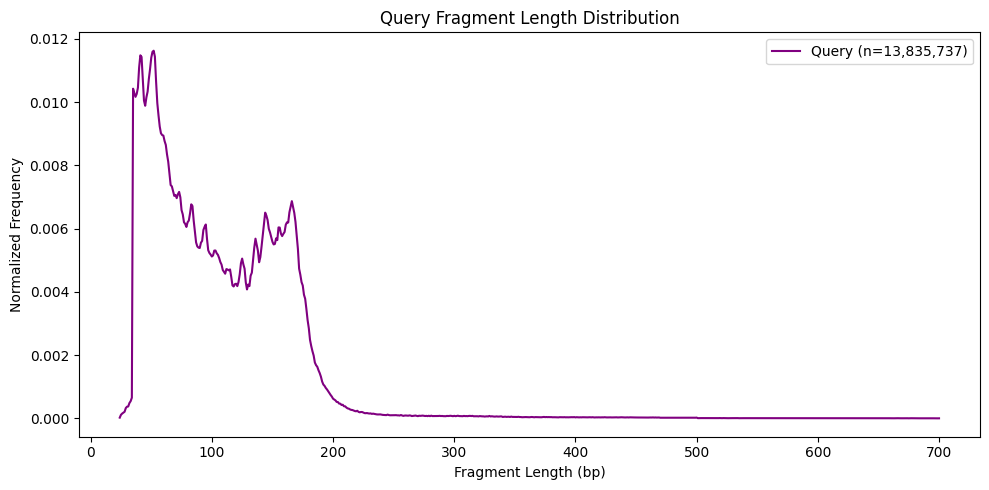

In [2]:
import matplotlib.pyplot as plt

# Calculate normalized frequencies
query_counts = query_series.value_counts().sort_index()
norm_query = query_counts / query_counts.sum()

# Plot query distribution
plt.figure(figsize=(10, 5))
plt.plot(norm_query.index, norm_query.values,
         label=f'Query (n={len(query_series):,})', color='purple')
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency")
plt.title("Query Fragment Length Distribution")
plt.legend()
plt.tight_layout()
plt.show()


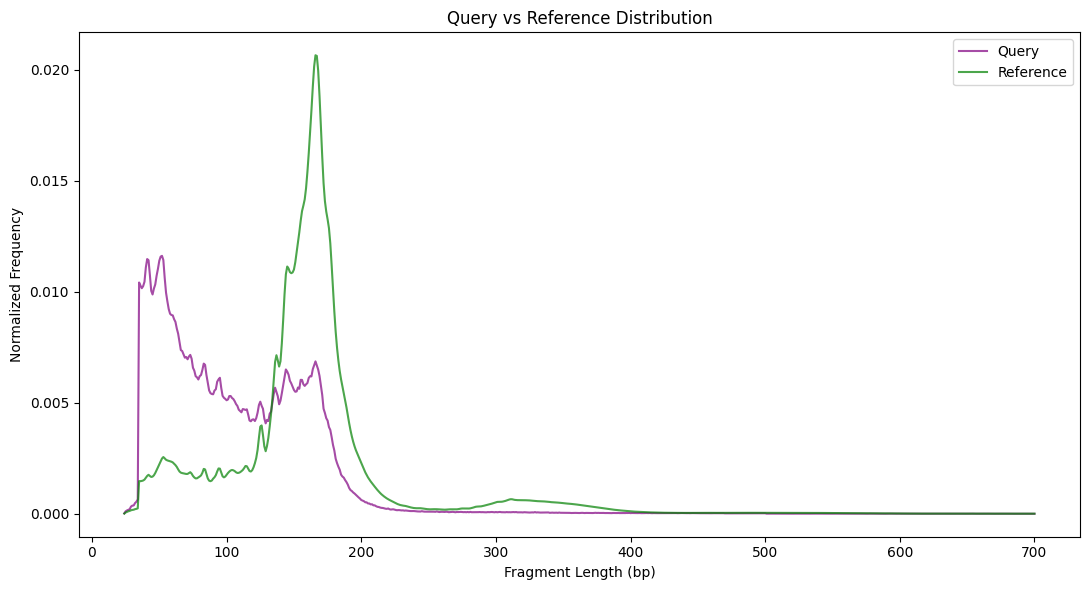

In [3]:

# Plot comparison
plt.figure(figsize=(11, 6))
plt.plot(norm_query.index, norm_query.values,
         label='Query', color='purple', alpha=0.7)
plt.plot(ref_freq.index, ref_freq.values,
         label='Reference', color='green', alpha=0.7)
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency")
plt.title("Query vs Reference Distribution")
plt.legend()
plt.tight_layout()
plt.show()

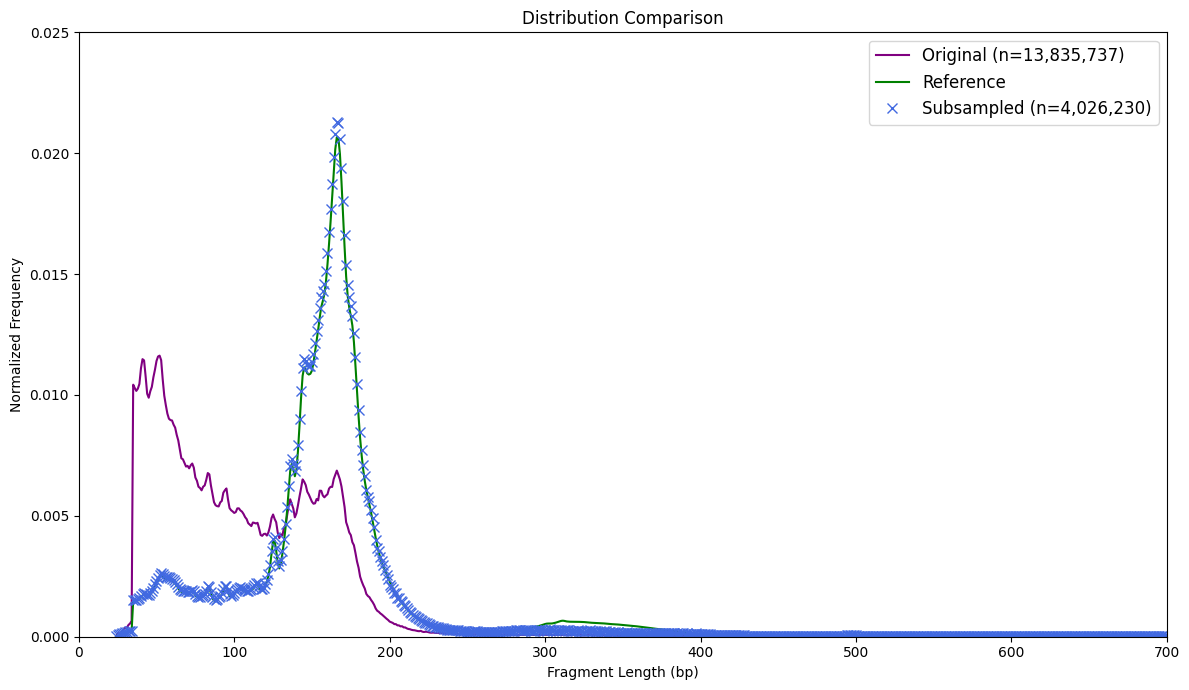

In [4]:
# Group fragments by length
length_groups = defaultdict(list)
for l in query_series:
    length_groups[l].append(l)

# Subsample to match reference distribution
target_size = int(len(query_series) * 0.3)
subsampled = []

for length, target_frac in ref_freq.items():
    if length in length_groups:
        pool = length_groups[length]
        desired_n = int(target_frac * target_size)
        subsampled.extend(random.sample(pool, min(desired_n, len(pool))))

# Plot final comparison
subsampled_series = pd.Series(subsampled)
subsampled_counts = subsampled_series.value_counts().sort_index()
norm_subsampled = subsampled_counts / subsampled_counts.sum()

plt.figure(figsize=(12, 7))
plt.plot(norm_query.index, norm_query.values,
         label=f'Original (n={len(query_series):,})', color='purple')
plt.plot(ref_freq.index, ref_freq.values,
         label='Reference', color='green')
plt.plot(norm_subsampled.index, norm_subsampled.values, 'x',
         label=f'Subsampled (n={len(subsampled):,})',
         color='royalblue', markersize=7)
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency")
plt.title("Distribution Comparison")
plt.xlim(0, 700)
plt.ylim(0, 0.025)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("distribution_comparison.png")
plt.show()